In [1]:
#defining Question
'''I want to investigate the following question: Which kinematic features show thew strongest difference between the signal and background events?'''


'I want to investigate the following question: Which kinematic features show thew strongest difference between the signal and background events?'

In [2]:
# load libaries
import pandas as pd
import numpy as np

In [3]:
# Load the dataset
df = pd.read_csv(
    r"C:\Users\emcuc\phys1655spring26-zhb9bv\Final project\Particle Physics Event Classification.csv",
    sep=",",
    header=0 # makes sure 1st row is treated as header not data
    )

## Replace -999 (missing value) with NaN 
# -999 means no jet
df_clean = df.replace(-999, np.nan)
# Print shape
print("Shape:", df_clean.shape)

# Display first few rows
print(df_clean.head())

# print column types, non-null counts
print(df_clean.info())

Shape: (250000, 33)
   EventId  DER_mass_MMC  DER_mass_transverse_met_lep  DER_mass_vis  DER_pt_h  \
0   100000       138.470                       51.655        97.827    27.980   
1   100001       160.937                       68.768       103.235    48.146   
2   100002           NaN                      162.172       125.953    35.635   
3   100003       143.905                       81.417        80.943     0.414   
4   100004       175.864                       16.915       134.805    16.405   

   DER_deltaeta_jet_jet  DER_mass_jet_jet  DER_prodeta_jet_jet  \
0                  0.91           124.711                2.666   
1                   NaN               NaN                  NaN   
2                   NaN               NaN                  NaN   
3                  9.00               NaN                  NaN   
4                   NaN               NaN                  NaN   

   DER_deltar_tau_lep  DER_pt_tot  ...  PRI_jet_num  PRI_jet_leading_pt  \
0               3.064

In [4]:
#count how many columns have more than 5% missing values
missing_counter = 0 #running counter

#iterate over all colmnns
for col in df.columns:
    missing_fraction = df_clean[col].isna().mean()
    # if more than 5% missing, add to counter
    if missing_fraction > 0.05:
        missing_counter += 1
print(f"Number of columns with >5% missing: {missing_counter}") 

Number of columns with >5% missing: 11


In [5]:
# Classify columns by data type
for col in df.columns:
    if df_clean[col].dtype == "float64":
        print(col, "is a float")
    elif df_clean[col].dtype == "int64":
        print(col, "is an integer")
    else:
        print(col, "is a string")        

EventId is an integer
DER_mass_MMC is a float
DER_mass_transverse_met_lep is a float
DER_mass_vis is a float
DER_pt_h is a float
DER_deltaeta_jet_jet is a float
DER_mass_jet_jet is a float
DER_prodeta_jet_jet is a float
DER_deltar_tau_lep is a float
DER_pt_tot is a float
DER_sum_pt is a float
DER_pt_ratio_lep_tau is a float
DER_met_phi_centrality is a float
DER_lep_eta_centrality is a float
PRI_tau_pt is a float
PRI_tau_eta is a float
PRI_tau_phi is a float
PRI_lep_pt is a float
PRI_lep_eta is a float
PRI_lep_phi is a float
PRI_met is a float
PRI_met_phi is a float
PRI_met_sumet is a float
PRI_jet_num is an integer
PRI_jet_leading_pt is a float
PRI_jet_leading_eta is a float
PRI_jet_leading_phi is a float
PRI_jet_subleading_pt is a float
PRI_jet_subleading_eta is a float
PRI_jet_subleading_phi is a float
PRI_jet_all_pt is a float
Weight is a float
Label is a string


In [6]:
# write and call twice function with docstring
def feature_separation(df, feature, label_col = "Label"):
    """
    Compute the seperation strength between signal and background 
    for a given kinematic feature using Cohen's d effect size 
    (difference beween two means divided by weighted average of standard devations between two groups)

    Parameters: df (dataset), feature (column to evaluate), 
         label_col (column that labels singal vs background) 
    Returns: float, Effect size. Higher = stringer seperation

    """
    signal = df[df[label_col] == "s"][feature].dropna()
    background = df[df[label_col] == "b"][feature].dropna()

    mean_sig = signal.mean()
    mean_bkg = background.mean()

    pooled_std = (((signal.std()**2 + background.std()**2) / 2) **0.5)
    return (mean_sig - mean_bkg) / pooled_std

#call the function twice
print(f"Seperation for feature 'DER_mass_jet_jet': {feature_separation(df_clean, 'DER_mass_jet_jet')}")
print(f"Seperation for feature 'DER_mass_transverse_met_lep': {feature_separation(df_clean, 'DER_mass_transverse_met_lep')}")

Seperation for feature 'DER_mass_jet_jet': 0.6491166909296519
Seperation for feature 'DER_mass_transverse_met_lep': -0.8074548995227314


In [7]:
# NumPy indexing
#convert column to array
mass_array= df_clean["DER_mass_MMC"].to_numpy()
# compute mean without empty values
print(f"Mean: {np.nanmean(mass_array)}")
# compute standard devation
print(f"STD: {np.nanstd(mass_array)}")
#count high mass values over 200 GeV using boolean masking
high_values = mass_array[mass_array>200]
print(f"Count > 200: {len(high_values)}")


Mean: 121.8585283595896
STD: 57.29802144982739
Count > 200: 12812


In [8]:
#dictionary
kinematic_features = ['DER_mass_MMC','DER_mass_transverse_met_lep','DER_mass_vis','DER_pt_h','DER_deltaeta_jet_jet','DER_mass_jet_jet','DER_prodeta_jet_jet','DER_deltar_tau_lep','DER_pt_tot','DER_sum_pt','DER_pt_ratio_lep_tau','DER_met_phi_centrality','DER_lep_eta_centrality','PRI_tau_pt','PRI_tau_eta','PRI_tau_phi','PRI_lep_pt','PRI_lep_eta','PRI_lep_phi','PRI_met','PRI_met_phi','PRI_met_sumet','PRI_jet_num','PRI_jet_leading_pt','PRI_jet_leading_eta','PRI_jet_leading_phi','PRI_jet_subleading_pt','PRI_jet_subleading_eta','PRI_jet_subleading_phi','PRI_jet_all_pt']
# empty dictionary
separation_score = {}

# compute seperation for each and store in dictionary
for feat in kinematic_features:
    separation_score[feat] = feature_separation(df_clean, feat, label_col="Label")

# want key with highest value
best_feature = max(separation_score, key=separation_score.get)

print(f"Kinematic feature with strongest singal/background seperation:{best_feature}")
print(f"Effect size: {separation_score[best_feature]}")


# The feature with strongest signal_background separation is DER_deltaeta_jet_jet with an effect size of ~0.69. 
# Ths feature measures the difference in pseudorapidity (how seperated jets are in detector) between two jets in an event.
# Jets are particles emitted when quarks or gluons are created in a collision and hadronize.
# Pseudorapidity describes how far a particle is emitted relative to the beam axis. 


Kinematic feature with strongest singal/background seperation:DER_deltaeta_jet_jet
Effect size: 0.6869497906505252


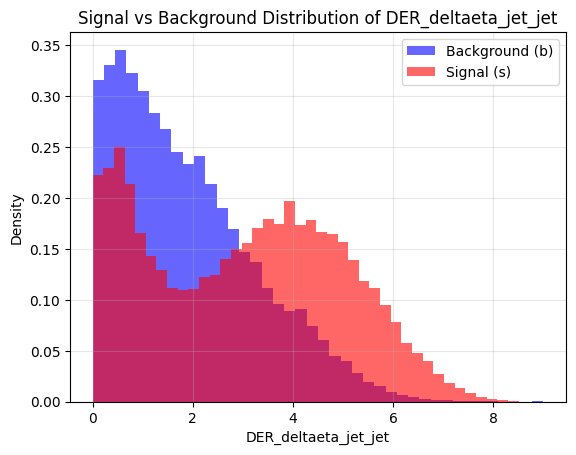

'\nBackground peaks near small small Δη. Signal peaks at larger Δη and small Δη because multiple Higgs production mechanisms produce different geometries.\nBoth distributions are right-skewed with a long tail, not Gaussian. \nBackground events tend to produce jets that are more central to beam axis and closer together.\n'

In [9]:
# Plot1:Histogram
import matplotlib.pyplot as plt

plt.hist(df_clean[df_clean["Label"] == "b"]["DER_deltaeta_jet_jet"].dropna(), bins=40, color="blue", alpha = 0.6, density = True, label="Background (b)") 
plt.hist(df_clean[df_clean["Label"] == "s"]["DER_deltaeta_jet_jet"].dropna(), bins=40, color="red", alpha = 0.6, density =True, label="Signal (s)")

plt.xlabel("DER_deltaeta_jet_jet")
plt.ylabel("Density")
plt.title("Signal vs Background Distribution of DER_deltaeta_jet_jet")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

'''
Background peaks near small small Δη. Signal peaks at larger Δη and small Δη because multiple Higgs production mechanisms produce different geometries.
Both distributions are right-skewed with a long tail, not Gaussian. 
Background events tend to produce jets that are more central to beam axis and closer together.
'''

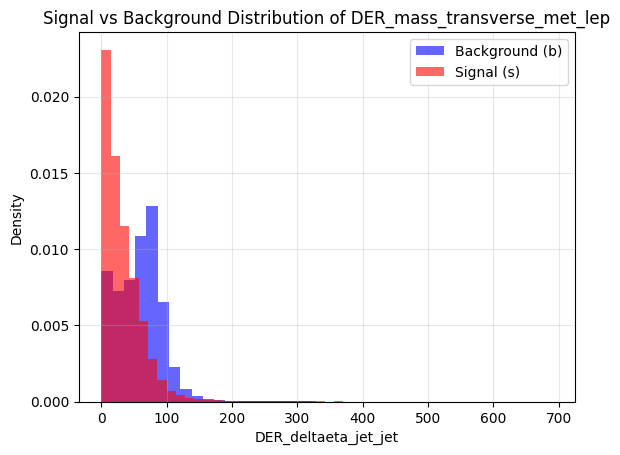

'\nEstimates mass of a particle that decayed into lepton and neutrino, using transverse components. \nSingal events tend to produce less transverse mass than background events due to number of neutrinos produced.\n'

In [ ]:
# 2nd Histogram: of greatest seperation
import matplotlib.pyplot as plt

plt.hist(df_clean[df_clean["Label"] == "b"]["DER_mass_transverse_met_lep"].dropna(), bins=40, color="blue", alpha = 0.6, density = True, label="Background (b)") 
plt.hist(df_clean[df_clean["Label"] == "s"]["DER_mass_transverse_met_lep"].dropna(), bins=40, color="red", alpha = 0.6, density =True, label="Signal (s)")

plt.xlabel("DER_deltaeta_jet_jet")
plt.ylabel("Density")
plt.title("Signal vs Background Distribution of DER_mass_transverse_met_lep")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

'''
Estimates mass of a particle that decayed into lepton and neutrino, using transverse components. 
Singal events tend to produce less transverse mass than background events due to number of neutrinos produced.
'''

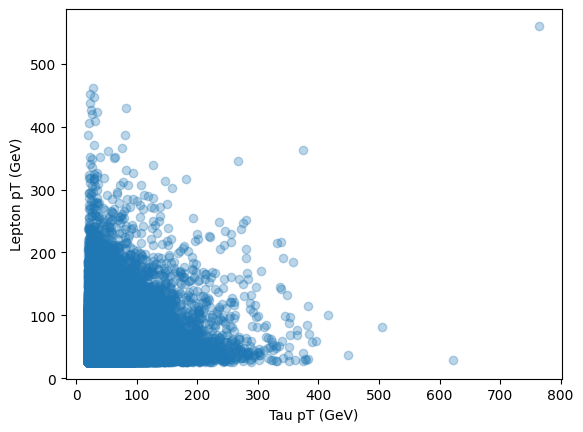

In [11]:
# Plot2: scatter plot comparing two kinematic features
plt.scatter(df["PRI_tau_pt"], df["PRI_lep_pt"], alpha = 0.3)
plt.xlabel("Tau pT (GeV)")
plt.ylabel("Lepton pT (GeV)")
plt.show()

# I chose a scatter plot becuase it is useful to identify correlations or patterns. 
# In this dataset, the scatter plot shows that high-momentum taus are not linearly associated with high-momentum leptons.
# The two quanties are largely independent.

In [12]:
# linear regression
from sklearn.linear_model import LinearRegression
#drop missing values
clean = df[["PRI_tau_pt", "PRI_lep_pt"]].dropna()
x = clean[["PRI_tau_pt"]]
y = clean[["PRI_lep_pt"]]

model = LinearRegression()
model.fit(x,y)

#access fit quality
r2 = model.score(x,y)

print(f"Slope: {model.coef_[0]}")
print(f"Intercept:v{model.intercept_}")
print(f"R^2: {r2}")

#Tau pT does not strongly predict lepton pT using a linear model. R^2 is very small so linear regression is not a good fit.

Slope: [0.10293385]
Intercept:v[42.67590373]
R^2: 0.010931403966336739
